In [1]:
#SAMPLE
import pandas as pd
df = pd.read_csv("Social_Media_Engagement.csv")

In [2]:
df.head()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach
0,1.0,harrislisa,TikTok,54217.0,3.0,0.0986,538.10,0.0490,1308.0
1,2.0,rhicks,LinkedIn,987518.0,5.0,0.0834,479.24,0.0174,13302.0
2,3.0,qthomas,Facebook,218870.0,3.0,0.1020,150.36,0.0318,11043.0
3,4.0,carlosholt,Instagram,207432.0,6.0,0.0834,932.62,0.0400,12074.0
4,5.0,parsonsashley,Facebook,350204.0,2.0,0.0642,504.44,0.0463,14083.0


In [3]:
df.tail()

,Account ID,Username,Platform,Follower Count,Posts Per Week,Engagement Rate,Ad Spend (USD),Conversion Rate,Campaign Reach
10011,12.0,tprice,TikTok,827728.0,6.0,0.0642,858.82,0.0342,29938.0
10012,13.0,robertpalmer,Instagram,637204.0,4.0,0.0642,924.61,0.0143,38384.0
10013,14.0,gilbertdavid,Twitter,866806.0,2.0,0.0642,757.24,0.0423,37502.0
10014,15.0,gsharp,Twitter,148081.0,3.0,0.0856,98.99,0.0118,25808.0
10015,16.0,katieking,Facebook,618549.0,3.0,0.0834,887.03,0.0249,7280.0


In [4]:
print("Shape:", df.shape)

Shape: (10016, 9)


In [5]:
sample_df = df.sample(frac=0.7, random_state=42)


In [6]:
print("Sample Shape:", sample_df.shape)

Sample Shape: (7011, 9)


In [7]:
#EXPLORE
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7011 entries, 1617 to 1936
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Account ID       6655 non-null   float64
 1   Username         6658 non-null   object 
 2   Platform         6663 non-null   object 
 3   Follower Count   6678 non-null   float64
 4   Posts Per Week   6653 non-null   float64
 5   Engagement Rate  6652 non-null   float64
 6   Ad Spend (USD)   6652 non-null   float64
 7   Conversion Rate  6657 non-null   float64
 8   Campaign Reach   6650 non-null   float64
dtypes: float64(7), object(2)
memory usage: 547.7+ KB


In [8]:
sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account ID,6655.0,4963.793539,2893.330676,1.0000,2465.5000,4934.0000,7471.5000,9997.000
Follower Count,6678.0,506843.709194,286368.578275,1449.0000,257192.0000,510704.5000,752860.2500,999919.000
Posts Per Week,6653.0,3.960770,1.983651,1.0000,2.0000,4.0000,6.0000,7.000
Engagement Rate,6652.0,0.086675,0.013243,0.0642,0.0834,0.0856,0.0986,0.102
Ad Spend (USD),6652.0,526.457195,282.602233,51.9500,274.7200,516.5000,785.3025,998.200
Conversion Rate,6657.0,0.029101,0.011404,0.0101,0.0192,0.0283,0.0391,0.050
Campaign Reach,6650.0,25272.418647,14168.502456,1005.0000,13064.2500,25324.0000,37607.2500,49991.000


In [9]:
sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account ID,6655.0,4963.793539,2893.330676,1.0000,2465.5000,4934.0000,7471.5000,9997.000
Follower Count,6678.0,506843.709194,286368.578275,1449.0000,257192.0000,510704.5000,752860.2500,999919.000
Posts Per Week,6653.0,3.960770,1.983651,1.0000,2.0000,4.0000,6.0000,7.000
Engagement Rate,6652.0,0.086675,0.013243,0.0642,0.0834,0.0856,0.0986,0.102
Ad Spend (USD),6652.0,526.457195,282.602233,51.9500,274.7200,516.5000,785.3025,998.200
Conversion Rate,6657.0,0.029101,0.011404,0.0101,0.0192,0.0283,0.0391,0.050
Campaign Reach,6650.0,25272.418647,14168.502456,1005.0000,13064.2500,25324.0000,37607.2500,49991.000


In [10]:
sample_df.describe(include='object').T

,count,unique,top,freq
Username,6658,989,michael16,21
Platform,6663,5,Facebook,1369


In [11]:
print(sample_df.isnull().sum())

Account ID         356
Username           353
Platform           348
Follower Count     333
Posts Per Week     358
Engagement Rate    359
Ad Spend (USD)     359
Conversion Rate    354
Campaign Reach     361
dtype: int64


In [12]:
print("Duplicate Rows:", sample_df.duplicated().sum())

Duplicate Rows: 1


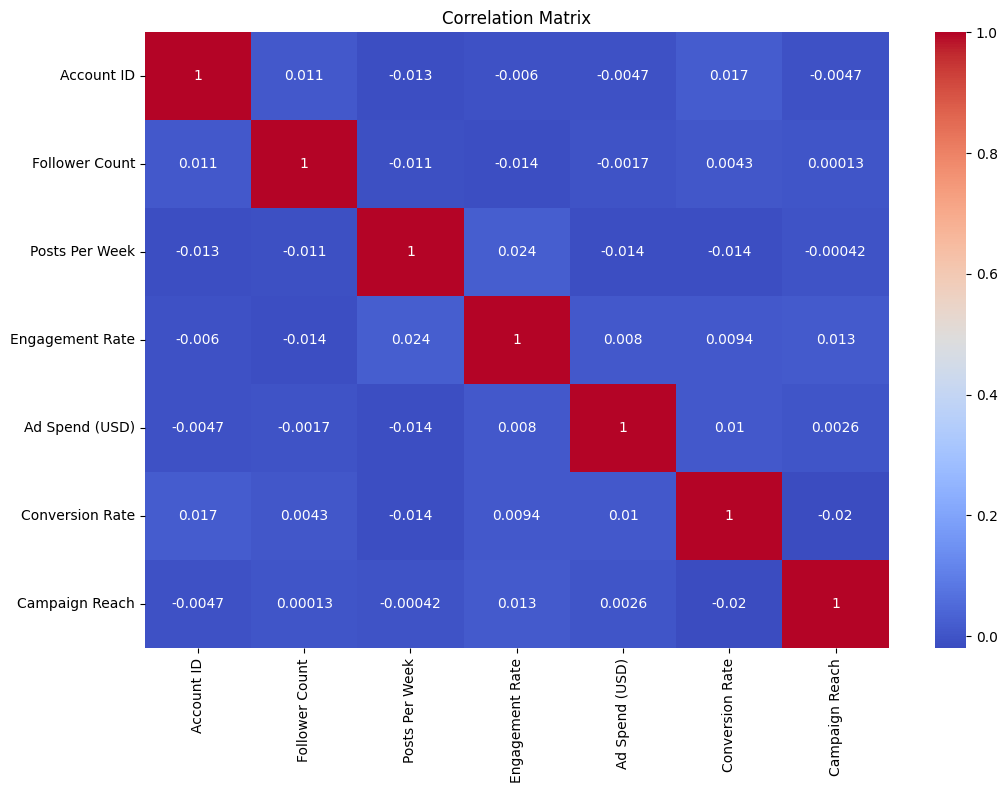

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = sample_df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

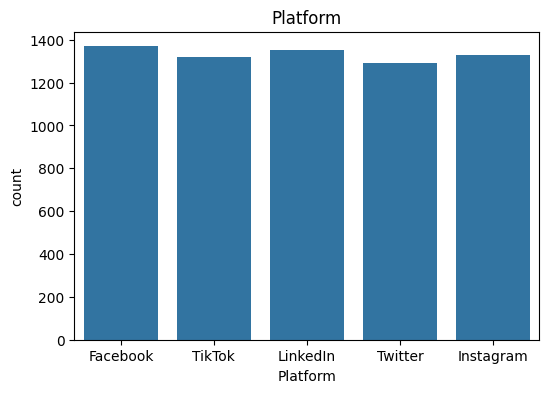

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=sample_df,
    x="Platform"
)

plt.title("Platform")
plt.show()

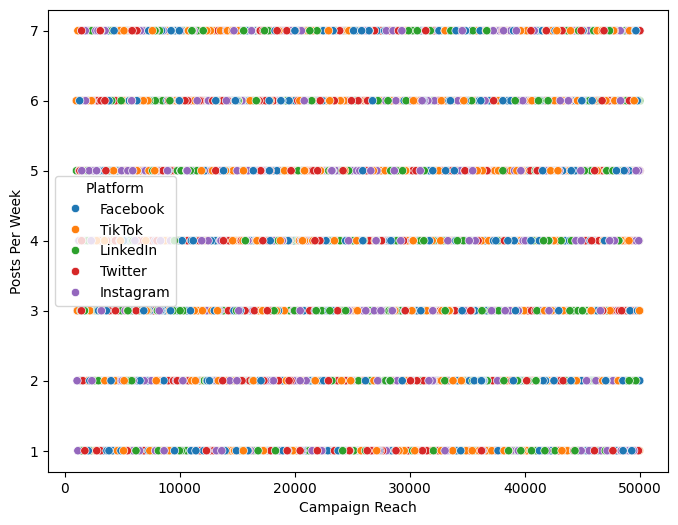

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x='Campaign Reach',
    y='Posts Per Week',
    hue='Platform'
)

plt.show()

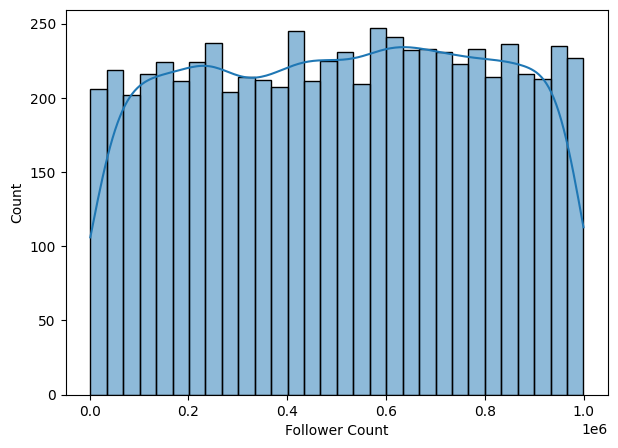

In [17]:
plt.figure(figsize=(7,5))

sns.histplot(
    sample_df["Follower Count"],
    bins=30,
    kde=True
)

plt.show()

In [18]:
#MODIFY
df_clean = sample_df.copy()

num_cols = df_clean.select_dtypes(include=['number']).columns

df_clean[num_cols] = df_clean[num_cols].fillna(
    df_clean[num_cols].median()
)

cat_cols = df_clean.select_dtypes(include=['object']).columns

df_clean[cat_cols] = df_clean[cat_cols].fillna(
    df_clean[cat_cols].mode().iloc[0]
)

In [19]:
df_clean.drop_duplicates(inplace=True)

In [22]:
df_clean.drop(
    columns=["Conversion Rate"],
    inplace=True
)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df_clean.select_dtypes(include='object').columns

for col in categorical_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [25]:
X = df_clean.drop("Platform", axis=1)
y = df_clean["Platform"]

X = X.drop(
    columns=["post_datetime","post_date"],
    errors="ignore"
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
#MODEL
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [29]:
y_pred = rf.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:",accuracy)

Accuracy: 0.20256776034236804


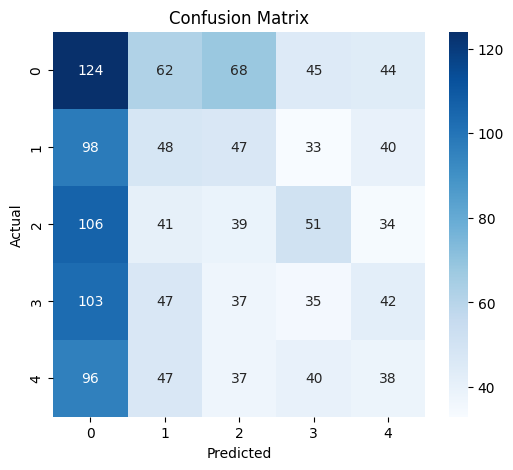

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()